In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os, sys
from pathlib import Path

cwd = Path().resolve()
if (cwd / "src").exists():
    project_root = cwd
elif (cwd.parent / "src").exists():
    project_root = cwd.parent
else:
    raise FileNotFoundError(f"'src' klasörü bulunamadı. current={cwd}")

sys.path.insert(0, str(project_root))

from src.pipeline import run_full_experiment
from src.preprocessing import cleaning_text

In [3]:
print(cleaning_text("This is a great place and I loved the food!"))

['great', 'place', 'love', 'food']


In [4]:
csv_path = str(project_root / "data" / "YelpData.csv")
%time results = run_full_experiment(csv_path=csv_path)

  File "c:\Users\alkan\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\alkan\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\alkan\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\alkan\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


Fitting 3 folds for each of 20 candidates, totalling 60 fits
CPU times: total: 16min 4s
Wall time: 6min 16s


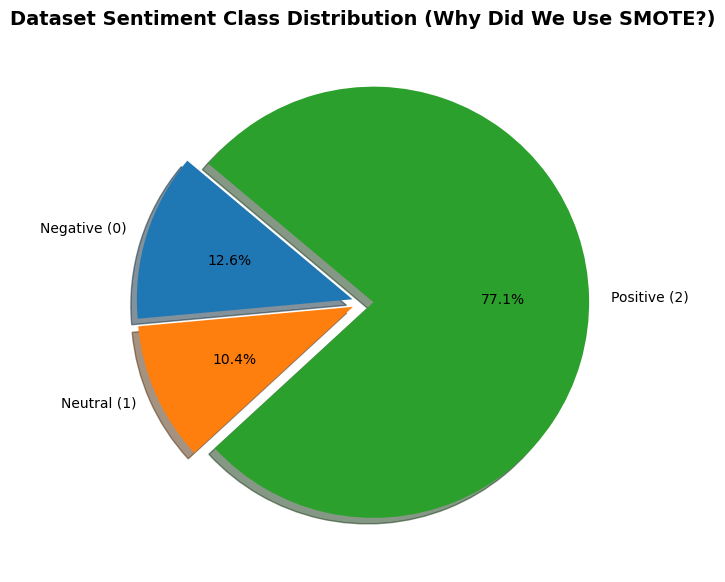

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


all_labels = pd.concat([results['y_train'], results['y_test']])
class_counts = all_labels.value_counts().sort_index() # 0, 1, 2 

label_names= ['Negative (0)', 'Neutral (1)', 'Positive (2)']

plt.figure(figsize=(7, 7))
plt.pie(class_counts, labels=label_names, autopct='%1.1f%%',
 startangle=140, shadow=True, explode=(0.05, 0.05, 0.05))
plt.title("Dataset Sentiment Class Distribution (Why Did We Use SMOTE?)", fontsize=14, fontweight='bold')
plt.show()

In [6]:
# Özet: Best Base Model Information
best_info = results["best_info"]
best_score = results["best_score"]

print("Best Combination :", best_info["comb_name"])
print("Best Model       :", best_info["model_name"])
print("Weighted F1      :", round(best_score, 4))

Best Combination : 4. Hybrid + SMOTE
Best Model       : XGBoost
Weighted F1      : 0.8377


In [7]:
# Classification Report
from pprint import pprint

print("\nClassification Report (base best model):\n")
print(best_info["classification_report"])


Classification Report (base best model):

              precision    recall  f1-score   support

           0     0.6886    0.7134    0.7008       499
           1     0.3662    0.4130    0.3882       414
           2     0.9316    0.9100    0.9207      3067

    accuracy                         0.8337      3980
   macro avg     0.6621    0.6788    0.6699      3980
weighted avg     0.8423    0.8337    0.8377      3980



In [8]:
# Hyperparameter Search Results (RandomizedSearchCV)

tuned_search = results.get("tuned_search")

if tuned_search is None:
    print("Tuning hasn't run yet")
else:
    print("CV Weighted F1 (best):", round(tuned_search.best_score_, 4))
    print("\nBest Params:")
    for k, v in tuned_search.best_params_.items():
        print(f"  {k}: {v}")

CV Weighted F1 (best): 0.8385

Best Params:
  model__subsample: 1.0
  model__n_estimators: 300
  model__max_depth: 9
  model__learning_rate: 0.05
  model__colsample_bytree: 0.9


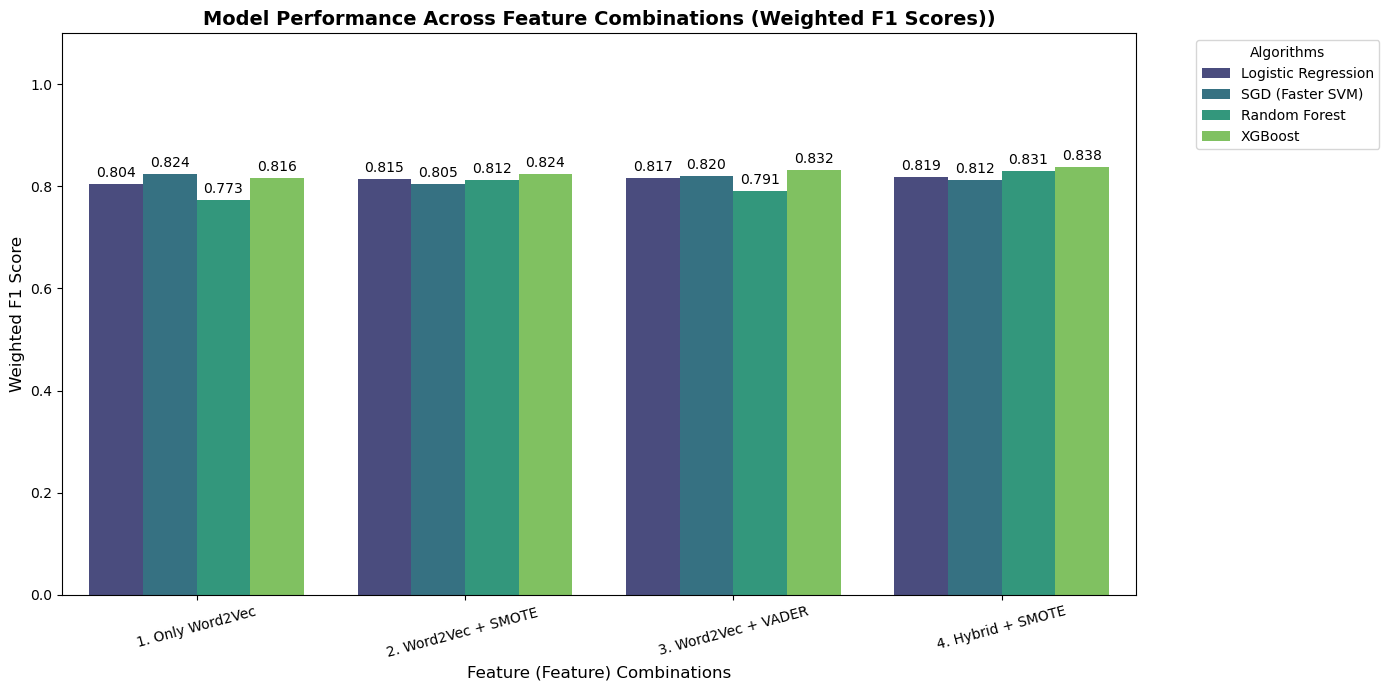

In [9]:
experiments_data = []
for res in results['results']:
    # Hiding NaN (Error) values
    if pd.notna(res.f1_score): 
        experiments_data.append({
            'Model': res.model_name,
            'Combination': res.combination,
            'F1_Score': res.f1_score
        })

df_results = pd.DataFrame(experiments_data)

plt.figure(figsize=(14, 7)) 

ax = sns.barplot(data=df_results, x='Combination', y='F1_Score', hue='Model', palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=10)

plt.title('Model Performance Across Feature Combinations (Weighted F1 Scores))', fontsize=14, fontweight='bold')
plt.xlabel('Feature (Feature) Combinations', fontsize=12)
plt.ylabel('Weighted F1 Score', fontsize=12)

plt.xticks(rotation=15) 

plt.ylim(0, 1.1) 

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Algorithms')
plt.tight_layout()
plt.show()

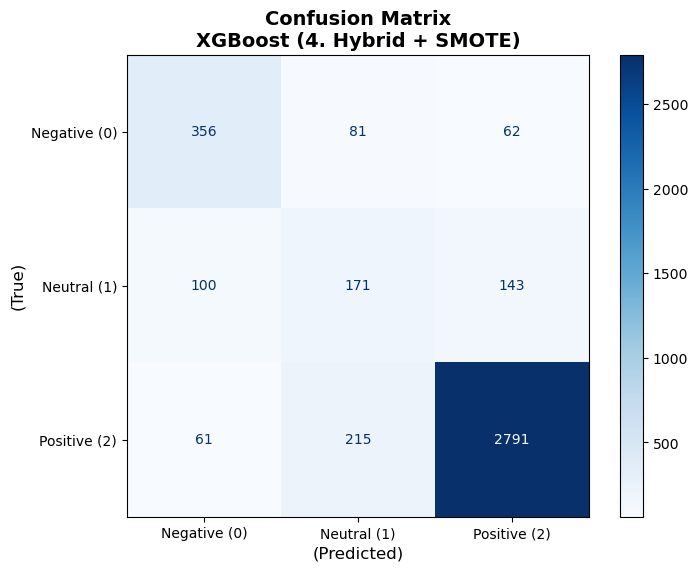

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get the test results of the best model
best_y_test = results['best_info']['y_test']
best_preds = results['best_info']['preds']
best_model_name = results['best_info']['model_name']
best_combination = results['best_info']['comb_name']

# Calculate the confusion matrix
cm = confusion_matrix(best_y_test, best_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

# Görselleştir
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title(f"Confusion Matrix\n{best_model_name} ({best_combination})", 
          fontsize=14, fontweight='bold')
plt.xlabel("(Predicted)", fontsize=12)
plt.ylabel("(True)", fontsize=12)
plt.show()